# Random Forest — From Scratch (NumPy only)

**Read `README.md` first.** Every block cites the section (§) it implements.

The forest is a ~10-line loop around lesson 05's tree, plus two doses of engineered randomness (README §2.2–2.3). Same mushroom data as lesson 05 — a controlled experiment.

In [1]:
# Block 1 — Imports.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(44)

## Block 2 — Same data, same split discipline *(README §1)*

Deliberately the lesson 05 dataset, so every improvement below is attributable to the FOREST, not the data.

In [2]:
df = pd.read_csv("data/mushroom_data.csv")
X = df[["cap_cm", "spore_density"]].values
y = (df.label == "poisonous").astype(int).values

idx = np.random.permutation(len(y)); cut = int(0.8 * len(y))
tr, te = idx[:cut], idx[cut:]
Xtr, Xte, ytr, yte = X[tr], X[te], y[tr], y[te]
print(f"{len(y)} mushrooms | train {len(tr)} / test {len(te)} | balance {y.mean():.0%} poisonous")

300 mushrooms | train 240 / test 60 | balance 50% poisonous


## Block 3 — Lesson 05's tree, with ONE new argument *(README §7)*

Identical gini / best_split / grow — except `best_split` now takes `feats`: the features it is ALLOWED to ask about (randomness source #2, README §2.3). One speed note: we scan 24 percentile thresholds per feature instead of every unique value — the standard engineering shortcut real libraries use; the algorithm is unchanged.

In [3]:
def gini(v):
    if len(v) == 0: return 0.0
    p = v.mean()
    return 1 - p*p - (1-p)**2

def best_split(X, y, feats):
    """Lesson 05 §3.2 — but only the features in `feats` may be asked about."""
    base, best = gini(y), None
    for f in feats:
        for t in np.percentile(X[:, f], np.linspace(4, 96, 24)):
            L = X[:, f] <= t
            if L.sum() == 0 or (~L).sum() == 0:
                continue
            g = L.mean()*gini(y[L]) + (~L).mean()*gini(y[~L])
            if best is None or base - g > best[0]:
                best = (base - g, f, t)
    return best

def grow(X, y, depth=0, max_depth=8, min_leaf=2, max_feats=2, rs=None):
    """Lesson 05 §3.3 — with per-split random feature subsets when rs is given."""
    if depth >= max_depth or len(np.unique(y)) == 1 or len(y) < 2*min_leaf:
        return {"leaf": True, "pred": int(round(y.mean()))}
    feats = rs.choice(X.shape[1], size=max_feats, replace=False) if rs is not None else range(X.shape[1])
    s = best_split(X, y, feats)
    if s is None or s[0] <= 1e-12:
        return {"leaf": True, "pred": int(round(y.mean()))}
    _, f, t = s
    L = X[:, f] <= t
    return {"leaf": False, "f": f, "t": t,
            "L": grow(X[L], y[L], depth+1, max_depth, min_leaf, max_feats, rs),
            "R": grow(X[~L], y[~L], depth+1, max_depth, min_leaf, max_feats, rs)}

def tree_predict(nd, X):
    if nd["leaf"]:
        return np.full(len(X), nd["pred"])
    L = X[:, nd["f"]] <= nd["t"]
    out = np.empty(len(X), dtype=int)
    out[L]  = tree_predict(nd["L"], X[L])
    out[~L] = tree_predict(nd["R"], X[~L])
    return out

print("Tree machinery rebuilt. New capability: a split can be FORBIDDEN from using a feature.")

Tree machinery rebuilt. New capability: a split can be FORBIDDEN from using a feature.


## Block 4 — Randomness source #1: the bootstrap *(README §3.1)*

Draw n rows WITH replacement: some repeat, and — verify the famous number — about 37% never get drawn. Those become the tree's out-of-bag rows (its free private exam, Block 9).

In [4]:
def bootstrap(n, rs):
    """README §2.2 — indices of a forged dataset: n draws with replacement."""
    return rs.integers(0, n, n)

rs = np.random.default_rng(0)
fracs = []
for _ in range(300):
    b = bootstrap(len(ytr), rs)
    fracs.append(1 - len(np.unique(b)) / len(ytr))
print(f"fraction of rows a bootstrap sample MISSES: {np.mean(fracs):.1%}  (theory: 1/e = {1/np.e:.1%} — README §3.1)")

fraction of rows a bootstrap sample MISSES: 36.6%  (theory: 1/e = 36.8% — README §3.1)


## Block 5 — The forest: a 10-line loop *(README §2.2 + §2.3)*

Each tree: its own bootstrap forgery (source #1), and per-split random feature menus (source #2, max_feats=1 of our 2). We remember each tree's bootstrap so Block 9 can find its out-of-bag rows.

In [5]:
def build_forest(Xtr, ytr, B=50, max_depth=8, max_feats=1, seed=0):
    """README §2.2–2.3 — B trees, each on a forged dataset, each with restricted questions."""
    rs = np.random.default_rng(seed)
    trees, boots = [], []
    for _ in range(B):
        b = bootstrap(len(ytr), rs)
        trees.append(grow(Xtr[b], ytr[b], max_depth=max_depth, max_feats=max_feats, rs=rs))
        boots.append(b)
    return trees, boots

forest, boots = build_forest(Xtr, ytr, B=50)
print(f"Forest of {len(forest)} trees grown. Each saw ~63% of the mushrooms and was")
print(f"randomly forbidden features at every split — 50 differently-flawed voters (README §2.3).")

Forest of 50 trees grown. Each saw ~63% of the mushrooms and was
randomly forbidden features at every split — 50 differently-flawed voters (README §2.3).


## Block 6 — The vote, and the head-to-head *(README §3.2 + §2.4)*

Prediction = majority vote (or the vote fraction, as a confidence). Then the controlled comparison: one lesson 05 tree vs the forest, same train/test split.

In [6]:
def forest_votes(trees, X):
    """README §3.2 — fraction of trees voting 'poisonous'."""
    return np.mean([tree_predict(t, X) for t in trees], axis=0)

def forest_predict(trees, X):
    return (forest_votes(trees, X) >= 0.5).astype(int)

single = grow(Xtr, ytr, max_depth=8)                      # lesson 05, no randomness
acc_single = (tree_predict(single, Xte) == yte).mean()
acc_forest = (forest_predict(forest, Xte) == yte).mean()
print(f"single tree (lesson 05): {acc_single:.0%}")
print(f"forest of 50           : {acc_forest:.0%}   <- same data, same tree algorithm inside; the vote is the difference")

conf = forest_votes(forest, Xte)
i_sure = int(np.argmax(np.abs(conf - 0.5)))
i_edge = int(np.argmin(np.abs(conf - 0.5)))
print(f"\nConfidence for free (README §5): mushroom #{i_sure}: {conf[i_sure]:.0%} of trees say poisonous (unanimous-ish),")
print(f"mushroom #{i_edge}: {conf[i_edge]:.0%} — the forest itself tells you it's shrugging.")

single tree (lesson 05): 85%
forest of 50           : 90%   <- same data, same tree algorithm inside; the vote is the difference

Confidence for free (README §5): mushroom #3: 0% of trees say poisonous (unanimous-ish),
mushroom #16: 50% — the forest itself tells you it's shrugging.


## Block 7 — Stability: twelve opinions vs the verdict *(README §2.1, live)*

Twelve individual tree boundaries (gray, jagged, all different) and the forest's voted boundary. Lesson 05's instability, cured before your eyes.

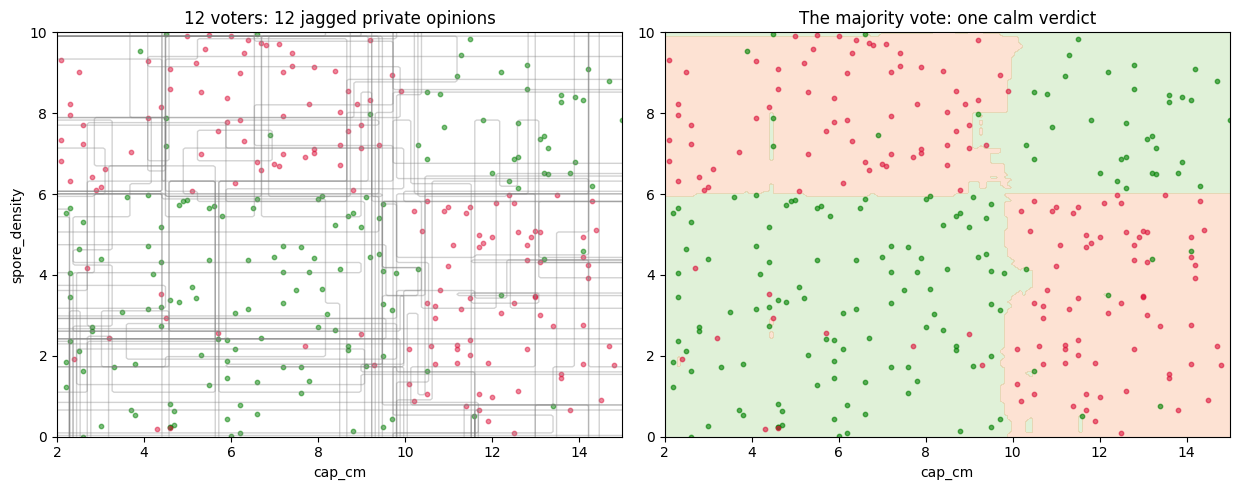

Private noise got outvoted; shared signal survived (README §2.1).


In [7]:
g0, g1 = np.meshgrid(np.linspace(2, 15, 160), np.linspace(0, 10, 160))
G = np.c_[g0.ravel(), g1.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
ax = axes[0]
for t in forest[:12]:
    ax.contour(g0, g1, tree_predict(t, G).reshape(g0.shape), levels=[0.5], colors="gray", alpha=0.35, linewidths=1)
ax.scatter(X[y==0,0], X[y==0,1], c="green", s=10, alpha=0.5)
ax.scatter(X[y==1,0], X[y==1,1], c="crimson", s=10, alpha=0.5)
ax.set_title("12 voters: 12 jagged private opinions"); ax.set_xlabel("cap_cm"); ax.set_ylabel("spore_density")

ax = axes[1]
Zf = forest_predict(forest, G).reshape(g0.shape)
ax.contourf(g0, g1, Zf, alpha=0.25, cmap="RdYlGn_r", levels=[-0.5, 0.5, 1.5])
ax.scatter(X[y==0,0], X[y==0,1], c="green", s=10, alpha=0.6)
ax.scatter(X[y==1,0], X[y==1,1], c="crimson", s=10, alpha=0.6)
ax.set_title("The majority vote: one calm verdict"); ax.set_xlabel("cap_cm")
plt.tight_layout(); plt.show()
print("Private noise got outvoted; shared signal survived (README §2.1).")

## Block 8 — The anti-knob: more trees never overfit *(README §4)*

Every previous lesson's star knob had a U-curve (K, depth). This one doesn't: test accuracy vs number of voters rises and PLATEAUS. §3.3's second term, live: (1−ρ)σ²/B only shrinks.

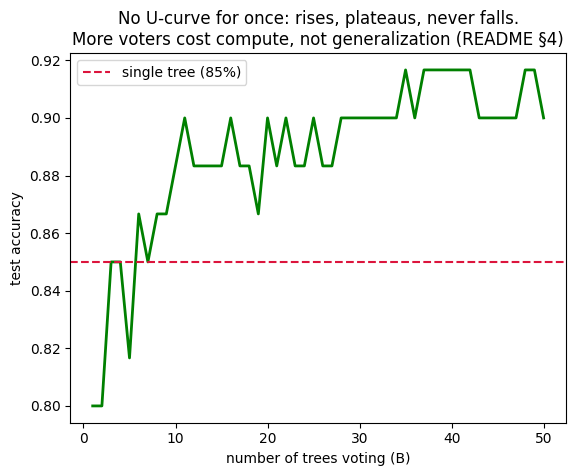

In [8]:
all_preds = np.array([tree_predict(t, Xte) for t in forest])   # (B, n_test) — vote with prefixes
Bs = range(1, len(forest) + 1)
accs = [((all_preds[:b].mean(axis=0) >= 0.5).astype(int) == yte).mean() for b in Bs]

plt.plot(list(Bs), accs, color="green", lw=2)
plt.axhline(acc_single, color="crimson", ls="--", lw=1.5, label=f"single tree ({acc_single:.0%})")
plt.xlabel("number of trees voting (B)"); plt.ylabel("test accuracy"); plt.legend()
plt.title("No U-curve for once: rises, plateaus, never falls.\nMore voters cost compute, not generalization (README §4)")
plt.show()

## Block 9 — The free exam: out-of-bag score *(README §3.4)*

Each mushroom is graded ONLY by the trees that never saw it (~37% of the forest, per Block 4). No test data spent — and watch how close it lands to the true test score.

In [9]:
oob_votes = np.zeros(len(ytr)); oob_counts = np.zeros(len(ytr))
for t, b in zip(forest, boots):
    unseen = np.setdiff1d(np.arange(len(ytr)), b)         # rows this tree never met
    if len(unseen) == 0: continue
    oob_votes[unseen] += tree_predict(t, Xtr[unseen])
    oob_counts[unseen] += 1

has_jury = oob_counts > 0
oob_pred = (oob_votes[has_jury] / oob_counts[has_jury] >= 0.5).astype(int)
oob_score = (oob_pred == ytr[has_jury]).mean()
print(f"average jury size per mushroom: {oob_counts.mean():.0f} of {len(forest)} trees (~37%, README §3.1)")
print(f"OOB score  : {oob_score:.0%}   <- computed WITHOUT touching the test set")
print(f"test score : {acc_forest:.0%}   <- the sealed exam agrees. Free validation is real (README §3.4)")

average jury size per mushroom: 18 of 50 trees (~37%, README §3.1)
OOB score  : 89%   <- computed WITHOUT touching the test set
test score : 90%   <- the sealed exam agrees. Free validation is real (README §3.4)


## Block 10 — What voting can't fix: the bias floor *(README §6)*

A dataset with a perfectly DIAGONAL boundary — the tree family's shared blind spot (axis-aligned staircases). Fifty staircases vote... into a staircase. Meanwhile lesson 02's humble line nails it. Moral: voting cancels private noise, never shared delusion (§3.3's ρσ² floor).

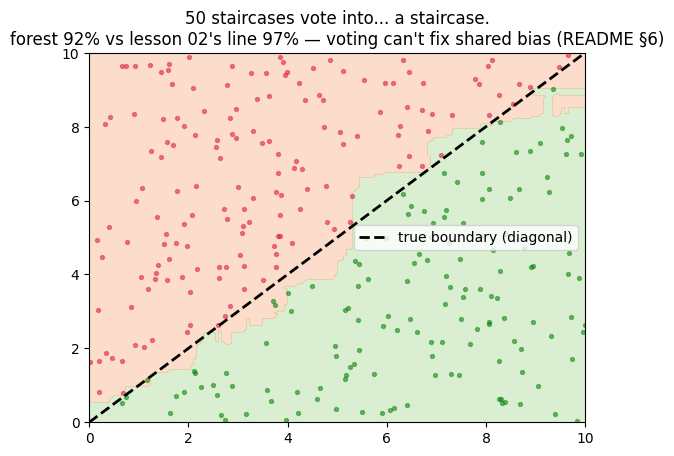

In [10]:
rs2 = np.random.default_rng(1)
Xd = rs2.uniform(0, 10, (300, 2))
yd = (Xd[:,1] > Xd[:,0]).astype(int)                       # boundary: the 45° diagonal
di = rs2.permutation(300); dtr, dte = di[:240], di[240:]

fd, _ = build_forest(Xd[dtr], yd[dtr], B=50, max_feats=1, seed=2)
acc_fd = (forest_predict(fd, Xd[dte]) == yd[dte]).mean()

mu, sd = Xd[dtr].mean(0), Xd[dtr].std(0)                   # lesson 02's model, 6 lines
Xs = (Xd[dtr]-mu)/sd; w = np.zeros(2); b = 0.0
for _ in range(3000):
    p = 1/(1+np.exp(-(Xs@w+b)))
    w -= 0.3*(Xs.T@(p-yd[dtr]))/len(Xs); b -= 0.3*np.mean(p-yd[dtr])
pl = (1/(1+np.exp(-(((Xd[dte]-mu)/sd)@w+b))) > 0.5).astype(int)
acc_lr = (pl == yd[dte]).mean()

Zd = forest_predict(fd, G := np.c_[np.meshgrid(np.linspace(0,10,160), np.linspace(0,10,160))[0].ravel(),
                                    np.meshgrid(np.linspace(0,10,160), np.linspace(0,10,160))[1].ravel()])
gg0, gg1 = np.meshgrid(np.linspace(0,10,160), np.linspace(0,10,160))
plt.contourf(gg0, gg1, Zd.reshape(gg0.shape), alpha=0.3, cmap="RdYlGn_r", levels=[-0.5, 0.5, 1.5])
plt.plot([0,10],[0,10],"k--",lw=2,label="true boundary (diagonal)")
plt.scatter(Xd[yd==0][:,0], Xd[yd==0][:,1], c="green", s=8, alpha=0.5)
plt.scatter(Xd[yd==1][:,0], Xd[yd==1][:,1], c="crimson", s=8, alpha=0.5)
plt.legend(); plt.title(f"50 staircases vote into... a staircase.\nforest {acc_fd:.0%} vs lesson 02's line {acc_lr:.0%} — voting can't fix shared bias (README §6)")
plt.show()

---
## What you now own

- The wisdom of crowds as engineering: forge datasets (bootstrap) + restrict questions (feature subsampling) = decorrelated voters whose errors cancel
- Bias vs variance, finally formal — and THE formula: Var = ρσ² + (1−ρ)σ²/B, which explains every design choice
- The anti-knob (more trees never overfit), the free exam (OOB ≈ test), confidence from vote fractions
- The honest limit: voting can't fix what all voters get wrong — which is exactly the problem lesson 08 (boosting) attacks

**Next:** `random_forest_with_library.ipynb` to verify against sklearn — then folder `07-svm`: the widest street between the classes.